# Metaeorite — Theory Primer & Equation ↔ Code Mapping

This document explains the physics and mathematics behind Metaeorite, links every implemented (or
not-yet-implemented) transformation to its scientific source, and derives the key formulas symbolically with
[SymPy](https://www.sympy.org/) so you can check them yourself instead of trusting a black box.

**Audience.**  
You do *not* need a general relativity or electromagnetics background to read this.  
Part 1 is a from-scratch primer.  
Parts 2-6 go deeper, module by module, each self-contained with its own references and caveats.  
Part 7 is a consolidated equation ↔ algorithm ↔ code lookup table (valid as of 7/21/2026).  
Part 8 is the bibliography.  
Part 9 is a glossary you can jump back to at any time.  

**How to run this notebook.**  
Only [SymPy](https://www.sympy.org/) is required (`pip install sympy`); nothing here touches the C++ build.  
Every derivation below is executed, not just asserted — re-run the cells to convince yourself, or change the symbols to explore other cases.

## Table of contents

1. [Primer for newcomers](#part1)
2. [Differential geometry & the spacetime metric](#part2) — foundation for `core::Metric`
3. [Transformation optics: Metric → Maxwell](#part3) — the Plebanski correspondence
4. [The inverse problem: Maxwell → Metric](#part4) — non-uniqueness and conformal invariance
5. [Effective medium theory: Geometry → Maxwell](#part5) — homogenization
6. [Symmetry & group theory: Maxwell → Geometry](#part6) — Neumann's principle
7. [Equation ↔ algorithm ↔ code mapping](#part7)
8. [Bibliography](#part8)
9. [Glossary](#part9)

In [1]:
import sympy as sp
from sympy import symbols, Matrix, sqrt, sin, cos, pi, diff, simplify, limit, solve
from IPython.display import display

sp.init_printing(use_unicode=True)

<a id="part1"></a>
## Part 1 — Primer for newcomers

Metaeorite connects four ideas that are normally taught in different courses, if at all. 
Here is each one in plain language, in the order the pipeline uses them.

**1. A metric is just "a rule for measuring distance."** 

In flat, everyday (Euclidean) space, the distance between two nearby points separated by $(dx, dy, dz)$ is $ds^2 = dx^2+dy^2+dz^2$.  
In special/general relativity we also fold time into the same object, and allow the "distances" to depend on where you are in spacetime 
(curved space) and to have a minus sign for the time direction:

$$ds^2 = g_{\mu\nu}\,dx^\mu dx^\nu ,\qquad \mu,\nu \in \{0,1,2,3\}.$$

The matrix $g_{\mu\nu}$ *is* the metric. Flat spacetime (no gravity) is the simple diagonal matrix
$\mathrm{diag}(-1,1,1,1)$, called the **Minkowski metric** — this is exactly what `core::Metric::minkowski()`
returns, and it is the one case Metaeorite currently understands completely.

**2. Maxwell's equations in _any_ medium (or curved spacetime) reduce to the same four equations, but with
different "constitutive relations."** 

In vacuum, $\mathbf D = \varepsilon_0 \mathbf E$ and $\mathbf B = \mu_0 \mathbf H$.  
Inside a medium (glass, a metamaterial, or — remarkably — curved spacetime itself)
these become tensor relations:

$$\mathbf D = \boldsymbol\varepsilon\,\mathbf E + \boldsymbol\xi\,\mathbf H, \qquad
  \mathbf B = \boldsymbol\zeta\,\mathbf E + \boldsymbol\mu\,\mathbf H,
$$

where $\boldsymbol\varepsilon,\boldsymbol\mu$ (permittivity/permeability) and $\boldsymbol\xi,\boldsymbol\zeta$
(magnetoelectric coupling) are now 3x3 matrices, not scalars. 

This four-tensor bundle is exactly `core::ConstitutiveRelations`, and it is the "common language" the whole 
project is built around.

**3. Transformation optics is the (surprising) fact that #1 and #2 are two views of the same math.**  
A gravitational field bends light the same way a cleverly designed medium would. So instead of building exotic
gravity, you can design a **metamaterial** — an engineered structure, usually much smaller than a wavelength —
whose effective $\boldsymbol\varepsilon,\boldsymbol\mu$ mimic the effect of a metric.  
This is how the famous "invisibility cloak" papers work (Part 3 below), and it's the reasoning direction of Metaeorite's `metric_to_maxwell` module.

**4. Going from a desired medium to an actual, buildable structure (and back) is homogenization.**  
You cannot manufacture a continuous tensor field; you can only arrange small repeating unit cells of ordinary materials
(metal, dielectric, air). **Effective medium theory** tells you what *bulk* $\varepsilon,\mu$ a fine periodic
structure looks like from far away (`geometry_to_maxwell`), and (harder, and non-unique) how to *invert* that to
find a structure realizing a *given* $\varepsilon,\mu$ (`maxwell_to_geometry`). **Group/representation theory**
narrows the search: a unit cell's rotational/reflective symmetry mathematically forbids most tensor components
outright (Part 6 below), which is exploited instead of blind numerical search (README, "Scientific Philosophy").

With that vocabulary, the architecture diagram in the [README](../README.md) is just: *metric ⇄ constitutive
relations ⇄ geometry*, with constitutive relations as the hub every module speaks.

<a id="part2"></a>
## Part 2 — Differential geometry & the spacetime metric

**Foundations needed:** tensors, indices, matrix inverses/determinants, and the idea of a *coordinate chart*
(the same physical situation can be described in Cartesian, cylindrical, or spherical coordinates, without
changing the underlying geometry — hence `core::CoordinateSystem`).

A metric $g_{\mu\nu}$ is a symmetric, non-degenerate $4\times4$ matrix (indices $0..3$, with $0$ the time
coordinate) with **Lorentzian signature** $(-,+,+,+)$: one negative eigenvalue (time), three positive
(space). It lets you:

- Measure invariant spacetime intervals $ds^2=g_{\mu\nu}dx^\mu dx^\nu$.
- Raise/lower indices via $g_{\mu\nu}$ and its matrix inverse $g^{\mu\nu}$.
- Compute the invariant volume element $\sqrt{-g}\,d^4x$, where $g=\det(g_{\mu\nu})$.

`core::Metric` stores exactly this: a `CoordinateSystem` (chart + dimension) and an `xt::xarray` holding
$g_{\mu\nu}$. It is deliberately dimension-agnostic (not hard-coded to 4x4) so the same type can later describe
volumetric/higher-dimensional future work (README, "Current Scope").

**References**
- Misner, C. W., Thorne, K. S., & Wheeler, J. A. (1973). *Gravitation*. W. H. Freeman. — the standard GR reference
  for metrics, index notation, and signature conventions used throughout this document.
- Wikipedia: [Metric tensor (general relativity)](https://en.wikipedia.org/wiki/Metric_tensor_(general_relativity))

**Caveats/limitations**
- Metaeorite currently only *exercises* one exact metric: `Metric::minkowski()` (flat spacetime). Constructing
  and validating physically meaningful curved metrics (Schwarzschild, Kerr, or purpose-built "cloaking" metrics)
  is not yet implemented — see [Part 7](#part7).

In [2]:
# The general 4x4 metric, split into blocks so we can talk about g00, the spatial 3-metric g_ij,
# and (for later, Part 4 reference) the "gravitomagnetic" cross terms g_0i.
g11, g12, g13, g22, g23, g33, N = symbols('g11 g12 g13 g22 g23 g33 N', positive=True)

G = Matrix([[g11, g12, g13],
            [g12, g22, g23],
            [g13, g23, g33]])          # spatial 3-metric (must be positive-definite: a valid "ruler")

g4 = sp.diag(-N**2, G)                  # block-diagonal 4-metric: no g_0i terms (a "non-rotating" spacetime)
display(g4)

# Minkowski is the special case G = Identity, N = 1
minkowski_subs = {g11: 1, g22: 1, g33: 1, g12: 0, g13: 0, g23: 0, N: 1}
display(g4.subs(minkowski_subs))   # matches core::Metric::minkowski()'s diag(-1, 1, 1, 1)

⎡  2               ⎤
⎢-N    0    0    0 ⎥
⎢                  ⎥
⎢ 0   g₁₁  g₁₂  g₁₃⎥
⎢                  ⎥
⎢ 0   g₁₂  g₂₂  g₂₃⎥
⎢                  ⎥
⎣ 0   g₁₃  g₂₃  g₃₃⎦

⎡-1  0  0  0⎤
⎢           ⎥
⎢0   1  0  0⎥
⎢           ⎥
⎢0   0  1  0⎥
⎢           ⎥
⎣0   0  0  1⎦

<a id="part3"></a>
## Part 3 — Transformation optics: Metric → Maxwell

**Foundations needed:** Part 2, plus Maxwell's equations in matter (constitutive relations, Part 1 item 2).

### The Plebanski correspondence

Plebanski (1960) showed that Maxwell's equations in a curved background (or in an arbitrary coordinate chart of
flat spacetime) are *algebraically identical* to Maxwell's equations in flat space filled with a
(generally bianisotropic) medium, provided the constitutive tensors are built from the metric as:

$$\varepsilon^{ij} = \mu^{ij} = -\frac{\sqrt{-g}}{g_{00}}\,g^{ij}, \qquad
  \Gamma^{i} = -\frac{g_{0i}}{g_{00}} \quad\text{(magnetoelectric/bianisotropic coupling)},$$

with $\mathbf D = \varepsilon\mathbf E + \boldsymbol\Gamma\times\mathbf H$,
$\mathbf B = \mu\mathbf H - \boldsymbol\Gamma\times\mathbf E$ (Gaussian-like units; see Leonhardt & Philbin 2006
for the full SI-unit bookkeeping and sign conventions, which vary between papers). The striking fact
$\varepsilon^{ij}=\mu^{ij}$ (numerically, as matrices) means the equivalent medium is always **impedance-matched
to vacuum** — the mathematical reason transformation-optics cloaks don't reflect light.

**What we implement now (the $g_{0i}=0$ case).** Metaeorite's current scope is "non-rotating," purely-spatial
coordinate transformations of an otherwise flat or simple background (README, "Current Scope": 2D metasurfaces,
frequency domain, linear media) — i.e. $g_{0i}=0$, so $\Gamma=0$ and the formula collapses to

$$\varepsilon^{ij}=\mu^{ij} = \frac{\sqrt{\det G}}{N}\,G^{ij}, \qquad G^{ij} := (G^{-1})^{ij},$$

which is exactly what `metric_to_maxwell::PlaceholderEngine` should generalize (it currently only handles the
trivial $G=I,\,N=1$ vacuum case and throws otherwise — see [Part 7](#part7)).

In [3]:
G_inv = simplify(G.inv())
epsilon = simplify(sqrt(G.det()) / N * G_inv)
mu = epsilon   # impedance matched: identical matrix to epsilon, not merely "similar"
display(epsilon)

# Sanity check against core::ConstitutiveRelations::vacuum(): flat metric -> identity constitutive tensors,
# exactly what metric_to_maxwell::PlaceholderEngine::transform() asserts for Metric::minkowski().
display(epsilon.subs(minkowski_subs))

⎡                                       2                                      ↪
⎢                          g₂₂⋅g₃₃ - g₂₃                                       ↪
⎢───────────────────────────────────────────────────────────────────  ──────── ↪
⎢     ______________________________________________________________       ___ ↪
⎢    ╱                      2      2                          2           ╱    ↪
⎢N⋅╲╱  g₁₁⋅g₂₂⋅g₃₃ - g₁₁⋅g₂₃  - g₁₂ ⋅g₃₃ + 2⋅g₁₂⋅g₁₃⋅g₂₃ - g₁₃ ⋅g₂₂   N⋅╲╱  g₁ ↪
⎢                                                                              ↪
⎢                                                                              ↪
⎢                        -g₁₂⋅g₃₃ + g₁₃⋅g₂₃                                    ↪
⎢───────────────────────────────────────────────────────────────────  ──────── ↪
⎢     ______________________________________________________________       ___ ↪
⎢    ╱                      2      2                          2           ╱    ↪
⎢N⋅╲╱  g₁₁⋅g₂₂⋅g₃₃ - g₁₁⋅g₂₃

⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

### Worked example: the Pendry-Schurig-Smith spherical cloak

This is the historical starting example of transformation optics and a good way to see the formula produce
something non-trivial. It is a *purely spatial* coordinate stretch of flat space (so it's the $g_{0i}=0$, in
fact even simpler "orthonormal Jacobian" special case above), squeezing a solid ball $0<r<R_2$ into a spherical
shell $R_1<r'<R_2$, hiding whatever is inside $r'<R_1$:

$$r' = R_1 + r\,\frac{R_2-R_1}{R_2}.$$

For a purely radial map (angles unchanged), the physical (orthonormal-frame) Jacobian is diagonal,
$\Lambda = \mathrm{diag}\!\left(\frac{dr'}{dr},\ \frac{r'}{r},\ \frac{r'}{r}\right)$, and the transformation-media
recipe (Pendry, Schurig & Smith 2006, eq. 4; equivalent to the Plebanski formula above for a flat virtual space)
is $\varepsilon'^{ii}=\mu'^{ii}=\Lambda_i^2/\det\Lambda$ (no sum). We derive $\varepsilon_r,\varepsilon_\theta$
below directly from this recipe — no formula is taken on faith, only the Jacobian recipe stated above — and then
check the one universally-cited hallmark of this construction: **the radial component must vanish at the inner
boundary** $r'\to R_1$, which is exactly what makes the enclosed region electromagnetically inaccessible.

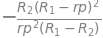

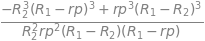

In [4]:
r, rp, R1, R2 = symbols('r rp R1 R2', positive=True)   # rp = r' (the mapped/physical radial coordinate)

rp_of_r = R1 + r * (R2 - R1) / R2
dr_p_dr = diff(rp_of_r, r)

Lambda_r = dr_p_dr                # dr'/dr
Lambda_t = rp_of_r / r            # r'/r  (the two tangential stretches, equal by spherical symmetry)
det_Lambda = Lambda_r * Lambda_t**2

eps_r_of_r = simplify(Lambda_r**2 / det_Lambda)          # radial component, still a function of r
eps_theta_of_r = simplify(Lambda_t**2 / det_Lambda)      # tangential components (theta == phi), fn of r

# Re-express everything in terms of the *physical* radius rp = r'(r), which is what a builder/reader cares about.
r_of_rp = solve(sp.Eq(rp_of_r, rp), r)[0]
eps_r = simplify(eps_r_of_r.subs(r, r_of_rp))
eps_theta = simplify(eps_theta_of_r.subs(r, r_of_rp))
display(eps_r, eps_theta)

In [5]:
# Cloaking sanity check: at the inner boundary (rp -> R1) the radial permittivity must vanish,
# which is precisely what makes the region r' < R1 electromagnetically inaccessible ("invisible").
display(eps_r.subs(rp, R1))   # -> 0, as required for a working cloak

**Caveats/limitations (Part 3)**
- Real cloaks built this way need $\varepsilon,\mu\to 0$ or $\to\infty$ at the boundaries — physically these are
  narrow-band, lossy, and hard to realize; see Schurig, Pendry & Smith (2006) for the reduced-parameter
  approximation that trades perfect invisibility for a realizable, slightly-scattering device.
- The formula above assumes a *linear*, reciprocal, non-dispersive medium and a purely spatial map of an
  otherwise-flat background. Time-dependent maps, dispersion, and nonlinearity are all out of current scope
  (README, "Current Scope").
- `metric_to_maxwell::PlaceholderEngine` only implements the trivial identity map; the general formula and the
  spherical-cloak special case derived above are **not yet implemented in code** (tracked in [Part 7](#part7)).

**References (Part 3)**
- Plebański, J. (1960). Electromagnetic waves in gravitational fields. *Physical Review*, 118(5), 1396–1408.
  [DOI: 10.1103/PhysRev.118.1396](https://doi.org/10.1103/PhysRev.118.1396)
- Leonhardt, U., & Philbin, T. G. (2006). General relativity in electrical engineering.
  *New Journal of Physics*, 8(10), 247. [DOI: 10.1088/1367-2630/8/10/247](https://doi.org/10.1088/1367-2630/8/10/247)
- Pendry, J. B., Schurig, D., & Smith, D. R. (2006). Controlling electromagnetic fields.
  *Science*, 312(5781), 1780–1782. [DOI: 10.1126/science.1125907](https://doi.org/10.1126/science.1125907)
- Schurig, D., Pendry, J. B., & Smith, D. R. (2006). Calculation of material properties and ray tracing in
  transformation media. *Optics Express*, 14(21), 9794–9804.
  [DOI: 10.1364/OE.14.009794](https://doi.org/10.1364/OE.14.009794)
- Cummer, S. A., Popa, B.-I., Schurig, D., Smith, D. R., & Pendry, J. (2006). Full-wave simulation of
  electromagnetic cloaking structures. *Physical Review E*, 74(3), 036621.
  [DOI: 10.1103/PhysRevE.74.036621](https://doi.org/10.1103/PhysRevE.74.036621)

<a id="part4"></a>
## Part 4 — The inverse problem: Maxwell → Metric

**Foundations needed:** Part 3 (the forward map), plus the idea of a *conformal transformation* (a rescaling
that stretches distances by a position-dependent factor $\Omega(x)$ but preserves all angles).

Going backward — given constitutive tensors $\varepsilon,\mu$, find "the" metric that produced them via
Plebanski's formula — is **not unique**. The clearest way to see this is that the formula is invariant under a
**conformal rescaling** of the spatial metric: if $G\to\Omega^2 G$ and $N\to\Omega N$ for *any* positive scalar
field $\Omega(x)$, the constitutive tensors are completely unchanged. So the map metric → medium is many-to-one,
and its inverse is fundamentally a *reconstruction with a family of candidates*, not a single answer — exactly
why `core::ReconstructionResult` models a *list* of confidence-weighted candidates plus assumption/caveat notes,
rather than returning one metric.

In [6]:
Omega = symbols('Omega', positive=True)   # an arbitrary position-dependent conformal factor

G_conf = Omega**2 * G
N_conf = Omega * N

G_conf_inv = simplify(G_conf.inv())
epsilon_conf = simplify(sqrt(G_conf.det()) / N_conf * G_conf_inv)

# If conformal invariance holds, this difference must simplify to the exact zero matrix,
# for *every* choice of Omega -- i.e. epsilon cannot "see" Omega at all.
display(simplify(epsilon_conf - epsilon))

⎡0  0  0⎤
⎢       ⎥
⎢0  0  0⎥
⎢       ⎥
⎣0  0  0⎦

**Caveats/limitations (Part 4)**
- Conformal invariance is only *one* source of non-uniqueness (chosen here because it is the cleanest to prove
  symbolically); coordinate choice, gauge freedom, and measurement noise/incompleteness all add further
  non-uniqueness in a real reconstruction problem.
- Because of this, `maxwell_to_metric::PlaceholderEngine` should always emit its result through
  `ReconstructionResult` with explicit confidence and assumptions rather than a single "the" metric — the
  current placeholder only exercises the single unambiguous case (vacuum-like constitutive relations ⇒
  Minkowski, confidence 1.0) where the ambiguity happens not to matter.

**References (Part 4)**
- Leonhardt, U. (2006). Optical conformal mapping. *Science*, 312(5781), 1777–1780.
  [DOI: 10.1126/science.1126493](https://doi.org/10.1126/science.1126493)
- Wikipedia: [Inverse problem](https://en.wikipedia.org/wiki/Inverse_problem),
  [Conformal map](https://en.wikipedia.org/wiki/Conformal_map)

<a id="part5"></a>
## Part 5 — Effective medium theory: Geometry → Maxwell

**Foundations needed:** Part 1 item 4 (homogenization in plain language), basic volume fractions.

When a unit cell mixes two materials (a host with permittivity $\varepsilon_h$ and spherical inclusions with
permittivity $\varepsilon_i$, volume fraction $f$) at length scales far below the wavelength, the structure
behaves — to an external field — as one *effective* homogeneous medium. The oldest and simplest closed-form
model is the **Maxwell Garnett mixing formula** (Maxwell Garnett, 1904):

$$\frac{\varepsilon_{\text{eff}} - \varepsilon_h}{\varepsilon_{\text{eff}} + 2\varepsilon_h}
  = f\,\frac{\varepsilon_i - \varepsilon_h}{\varepsilon_i + 2\varepsilon_h}.$$

Solving for $\varepsilon_{\text{eff}}$ gives the closed form used below. This is exactly the kind of
`core::Geometry → core::ConstitutiveRelations` mapping `geometry_to_maxwell` is meant to compute.

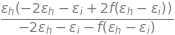

In [7]:
eps_h, eps_i, f = symbols('epsilon_h epsilon_i f', positive=True)  # host permittivity, inclusion permittivity, fill fraction

beta = (eps_i - eps_h) / (eps_i + 2*eps_h)          # single-sphere polarizability factor
eps_eff_mg = simplify(eps_h * (1 + 2*f*beta) / (1 - f*beta))
display(eps_eff_mg)

# Sanity limits: no inclusions -> pure host; all inclusions -> pure inclusion material.
display(limit(eps_eff_mg, f, 0))   # -> epsilon_h
display(limit(eps_eff_mg, f, 1))   # -> epsilon_i

**Caveats/limitations (Part 5)**
- Maxwell Garnett is a **dilute approximation**: it assumes well-separated, non-interacting spherical
  inclusions, and becomes inaccurate at high fill fraction or near a percolation threshold. It also silently
  breaks the host/inclusion symmetry (swapping which material is "host" gives a different answer), unlike the
  symmetric Bruggeman effective-medium formula, which is the standard alternative for denser mixtures.
- Real metamaterial unit cells are usually *not* spherical, *not* dilute, and often resonant/dispersive near the
  operating frequency — full-wave numerical homogenization (S-parameter retrieval, field-averaging) is typically
  needed in practice; the closed-form model above is a first-order, first-implementable baseline.
- `geometry_to_maxwell::PlaceholderEngine` currently only recognizes the trivial `dimension()==0` "free space"
  geometry and returns vacuum constitutive relations; Maxwell Garnett (or any mixing rule) is **not yet
  implemented** (see [Part 7](#part7)).

**References (Part 5)**
- Garnett, J. C. M. (1904). Colours in metal glasses and in metallic films.
  *Philosophical Transactions of the Royal Society A*, 203, 385–420.
  [DOI: 10.1098/rsta.1904.0024](https://doi.org/10.1098/rsta.1904.0024)
- Bruggeman, D. A. G. (1935). Berechnung verschiedener physikalischer Konstanten von heterogenen Substanzen.
  *Annalen der Physik*, 416(7), 636–664. [DOI: 10.1002/andp.19354160705](https://doi.org/10.1002/andp.19354160705)
- Sihvola, A. (1999). *Electromagnetic Mixing Formulas and Applications*. IET.
- Milton, G. W. (2002). *The Theory of Composites*. Cambridge University Press.

<a id="part6"></a>
## Part 6 — Symmetry & group theory: Maxwell → Geometry

**Foundations needed:** rotation matrices, and the idea of an *invariance constraint* (a tensor "looks the same"
under a symmetry operation if applying that operation to it leaves it unchanged).

**Neumann's principle** (Neumann, 1885) states that any macroscopic physical property tensor of a material must
be invariant under every symmetry operation of that material's point group. Concretely: if a unit cell has a
symmetry $R$ (e.g. a 90° rotation), its effective permittivity tensor $M$ must satisfy $R M R^{\mathsf T} = M$.
This is enormously useful in *both* directions Metaeorite cares about: it *constrains* what constitutive tensors
a given geometry can produce (`geometry_to_maxwell`), and it *prunes the search space* when reconstructing a
geometry from a desired tensor (`maxwell_to_geometry`) — most candidate tensors are simply forbidden by symmetry,
independent of any physics simulation (README, "Scientific Philosophy").

### Worked example: a unit cell with 4-fold (C4) rotational symmetry about $z$

We solve $R_z(\pi/2)\,M\,R_z(\pi/2)^{\mathsf T} = M$ for a general symmetric $3\times3$ tensor $M$, and show the
familiar result: 4-fold symmetry forces $M_{xx}=M_{yy}$ and kills all off-diagonal terms, leaving only two
independent constants ($M_{xx}=M_{yy}$ and $M_{zz}$) — i.e. the effective medium must be **uniaxial**.

In [8]:
a11, a12, a13, a22, a23, a33 = symbols('a11 a12 a13 a22 a23 a33')

M = Matrix([[a11, a12, a13],
            [a12, a22, a23],
            [a13, a23, a33]])                       # the most general symmetric rank-2 tensor

theta = pi / 2                                       # 90 degrees: the generator of the C4 rotation group about z
Rz = Matrix([[cos(theta), -sin(theta), 0],
             [sin(theta),  cos(theta), 0],
             [0,           0,          1]])

invariance_equations = [sp.Eq(lhs, rhs) for lhs, rhs in
                         zip((Rz * M * Rz.T), M) if simplify(lhs - rhs) != 0]
display(invariance_equations)

constraints = solve(invariance_equations, [a11, a12, a13, a22, a23, a33], dict=True)
display(constraints)

In [9]:
# The surviving tensor form once C4-about-z symmetry is enforced: uniaxial, only two independent constants.
display(M.subs(constraints[0]))

⎡a₂₂   0    0 ⎤
⎢             ⎥
⎢ 0   a₂₂   0 ⎥
⎢             ⎥
⎣ 0    0   a₃₃⎦

**Caveats/limitations (Part 6)**
- Neumann's principle gives *necessary* constraints, not sufficient ones — symmetry tells you what tensor forms
  are *allowed*, never what the actual numerical values are (those still require geometry/physics, e.g. Part 5's
  homogenization). It is a pruning tool, not a full solver.
- Real unit cells can have symmetry only approximately (fabrication tolerances) or may combine several point
  groups' worth of constraints at once (e.g. mixed rotational + mirror symmetries); the single-generator C4
  example above is the simplest illustrative case, not a general algorithm.
- `core::SymmetryClassification` exists as a vocabulary type, but no engine yet consumes point-group data to
  constrain or filter reconstruction candidates — the derivation above is the intended algorithm, not yet wired
  into `maxwell_to_geometry` or `geometry_to_maxwell` (see [Part 7](#part7)).

**References (Part 6)**
- Neumann, F. E. (1885). *Vorlesungen über die Theorie der Elasticität der festen Körper*. Teubner.
  (Origin of Neumann's principle.)
- Nye, J. F. (1957). *Physical Properties of Crystals: Their Representation by Tensors and Matrices*.
  Oxford University Press. — the standard modern reference for applying Neumann's principle to material tensors.
- Bradley, C. J., & Cracknell, A. P. (1972). *The Mathematical Theory of Symmetry in Solids*. Oxford University
  Press. — group-representation-theory background for point groups.

<a id="part7"></a>
## Part 7 — Equation ↔ algorithm ↔ code mapping

| # | Equation / theorem | Algorithm | Code location | Status |
|---|---|---|---|---|
| E1 | $ds^2=g_{\mu\nu}dx^\mu dx^\nu$, signature $(-,+,+,+)$ | Metric validation (square, rank-2) | [`modules/core/include/metaeorite/core/Metric.hpp`](../modules/core/include/metaeorite/core/Metric.hpp), [`Metric.cpp`](../modules/core/src/Metric.cpp) | ✅ Implemented (`Metric`, `minkowski()`, `isMinkowski()`) |
| E2 | $\mathbf D=\varepsilon\mathbf E+\xi\mathbf H,\ \mathbf B=\zeta\mathbf E+\mu\mathbf H$ | Constitutive tensor storage & vacuum check | [`ConstitutiveRelations.hpp`](../modules/core/include/metaeorite/core/ConstitutiveRelations.hpp), [`.cpp`](../modules/core/src/ConstitutiveRelations.cpp) | ✅ Implemented (`vacuum()`, `isVacuumLike()`) |
| E3 | Plebański: $\varepsilon^{ij}=\mu^{ij}=\sqrt{-g}/g_{00}\cdot g^{ij}$ (general), reduced $g_{0i}=0$ form (Part 3) | Metric → Maxwell forward transform | [`modules/metric_to_maxwell/`](../modules/metric_to_maxwell/) `PlaceholderEngine::transform()` | 🔶 Only the trivial $G=I,N=1$ vacuum case implemented; general formula **not yet implemented** |
| E4 | Conformal invariance $G\to\Omega^2G \Rightarrow \varepsilon$ unchanged (Part 4) | Maxwell → Metric inverse reconstruction, multi-candidate output | [`modules/maxwell_to_metric/`](../modules/maxwell_to_metric/) `PlaceholderEngine::transform()`, [`ReconstructionResult.hpp`](../modules/core/include/metaeorite/core/ReconstructionResult.hpp) | 🔶 Only the unambiguous vacuum-like → Minkowski case implemented; general non-unique reconstruction **not yet implemented** |
| E5 | Pendry-Schurig-Smith spherical cloak $\varepsilon_r,\varepsilon_\theta$ (Part 3) | Closed-form transformation-media worked example | *(none yet — derivation lives only in this notebook)* | ⬜ Not implemented; candidate first non-trivial engine case |
| E6 | Maxwell Garnett mixing formula (Part 5) | Geometry → Maxwell homogenization | [`modules/geometry_to_maxwell/`](../modules/geometry_to_maxwell/) `PlaceholderEngine::transform()` | 🔶 Only `dimension()==0` free-space case implemented; mixing-rule homogenization **not yet implemented** |
| E7 | Neumann's principle $RMR^{\mathsf T}=M$ (Part 6) | Symmetry-constrained candidate filtering | [`SymmetryClassification.hpp`](../modules/core/include/metaeorite/core/SymmetryClassification.hpp) (vocabulary type only) | ⬜ No engine consumes this yet; see [`modules/maxwell_to_geometry/`](../modules/maxwell_to_geometry/) |
| E8 | Vacuum baseline (identity for all of the above) | Round-trip pipeline demonstration | [`modules/pipeline/`](../modules/pipeline/) `Pipeline`, [`apps/metaeorite_cli/main.cpp`](../apps/metaeorite_cli/main.cpp) | ✅ Implemented & verified (all 16 tests passing, CLI demo runs end to end) |

Legend: ✅ implemented and tested · 🔶 partially implemented (baseline/placeholder only) · ⬜ not yet implemented.

<a id="part8"></a>
## Part 8 — Bibliography

**Primary literature**
- Plebański, J. (1960). Electromagnetic waves in gravitational fields. *Physical Review*, 118(5), 1396–1408.
  [DOI: 10.1103/PhysRev.118.1396](https://doi.org/10.1103/PhysRev.118.1396)
- Leonhardt, U., & Philbin, T. G. (2006). General relativity in electrical engineering.
  *New Journal of Physics*, 8(10), 247. [DOI: 10.1088/1367-2630/8/10/247](https://doi.org/10.1088/1367-2630/8/10/247)
- Leonhardt, U. (2006). Optical conformal mapping. *Science*, 312(5781), 1777–1780.
  [DOI: 10.1126/science.1126493](https://doi.org/10.1126/science.1126493)
- Pendry, J. B., Schurig, D., & Smith, D. R. (2006). Controlling electromagnetic fields.
  *Science*, 312(5781), 1780–1782. [DOI: 10.1126/science.1125907](https://doi.org/10.1126/science.1125907)
- Schurig, D., Pendry, J. B., & Smith, D. R. (2006). Calculation of material properties and ray tracing in
  transformation media. *Optics Express*, 14(21), 9794–9804.
  [DOI: 10.1364/OE.14.009794](https://doi.org/10.1364/OE.14.009794)
- Cummer, S. A., Popa, B.-I., Schurig, D., Smith, D. R., & Pendry, J. (2006). Full-wave simulation of
  electromagnetic cloaking structures. *Physical Review E*, 74(3), 036621.
  [DOI: 10.1103/PhysRevE.74.036621](https://doi.org/10.1103/PhysRevE.74.036621)
- Garnett, J. C. M. (1904). Colours in metal glasses and in metallic films.
  *Philosophical Transactions of the Royal Society A*, 203, 385–420.
  [DOI: 10.1098/rsta.1904.0024](https://doi.org/10.1098/rsta.1904.0024)
- Bruggeman, D. A. G. (1935). Berechnung verschiedener physikalischer Konstanten von heterogenen Substanzen.
  *Annalen der Physik*, 416(7), 636–664. [DOI: 10.1002/andp.19354160705](https://doi.org/10.1002/andp.19354160705)

**Books**
- Misner, C. W., Thorne, K. S., & Wheeler, J. A. (1973). *Gravitation*. W. H. Freeman.
- Sihvola, A. (1999). *Electromagnetic Mixing Formulas and Applications*. IET.
- Milton, G. W. (2002). *The Theory of Composites*. Cambridge University Press.
- Neumann, F. E. (1885). *Vorlesungen über die Theorie der Elasticität der festen Körper*. Teubner.
- Nye, J. F. (1957). *Physical Properties of Crystals*. Oxford University Press.
- Bradley, C. J., & Cracknell, A. P. (1972). *The Mathematical Theory of Symmetry in Solids*. Oxford University Press.

**Background reading**
- Wikipedia: [Metric tensor (general relativity)](https://en.wikipedia.org/wiki/Metric_tensor_(general_relativity)),
  [Inverse problem](https://en.wikipedia.org/wiki/Inverse_problem),
  [Conformal map](https://en.wikipedia.org/wiki/Conformal_map),
  [Metamaterial](https://en.wikipedia.org/wiki/Metamaterial),
  [Transformation optics](https://en.wikipedia.org/wiki/Transformation_optics),
  [Effective medium approximations](https://en.wikipedia.org/wiki/Effective_medium_approximations)

**Software dependencies used by the C++ implementation**
- [Eigen](https://eigen.tuxfamily.org/) — linear algebra (constitutive tensor matrices)
- [xtensor](https://xtensor.readthedocs.io/) — n-dimensional array support (metric tensor storage)
- [Catch2](https://github.com/catchorg/Catch2) — unit/integration testing
- [CPM.cmake](https://github.com/cpm-cmake/CPM.cmake) — CMake dependency management
- [SymPy](https://www.sympy.org/) — symbolic derivations used throughout this notebook

<a id="part9"></a>
## Part 9 — Glossary

- **Metric ($g_{\mu\nu}$):** a symmetric matrix defining how to measure distances/intervals in a given
  coordinate chart; encodes the geometry of spacetime (or space).
- **Minkowski metric:** the flat, gravity-free metric $\mathrm{diag}(-1,1,1,1)$; the baseline case Metaeorite
  currently implements exactly.
- **Constitutive relations:** the tensor equations ($\varepsilon,\mu,\xi,\zeta$) linking $\mathbf D,\mathbf B$ to
  $\mathbf E,\mathbf H$ inside a medium; the "common language" hub of the whole project.
- **Bianisotropic / magnetoelectric coupling ($\xi,\zeta$):** cross-terms where an electric field induces a
  magnetic response (or vice versa); zero for ordinary, non-rotating, simple media.
- **Impedance-matched:** a medium whose wave impedance equals that of the surrounding medium (usually vacuum),
  so no reflection occurs at the boundary — the defining feature of ideal transformation-optics media.
- **Transformation optics:** the design principle of engineering a medium's $\varepsilon,\mu$ to reproduce the
  optical effect of a chosen coordinate transformation or metric.
- **Conformal transformation:** a position-dependent rescaling $x\to\Omega(x)\,x$ that preserves angles but not
  distances; the source of non-uniqueness in Part 4.
- **Homogenization / effective medium theory:** replacing a fine, structured composite with a single equivalent
  bulk material, valid when the structure's length scale is much smaller than the wavelength.
- **Maxwell Garnett formula:** a closed-form dilute-limit mixing rule for the effective permittivity of
  spherical inclusions in a host medium.
- **Point group / Neumann's principle:** the set of rotation/reflection symmetries of a unit cell; Neumann's
  principle says any physical property tensor of that cell must be invariant under all of them.
- **`core::ReconstructionResult`:** the project's vocabulary type for representing an *inverse*-problem answer as
  a ranked list of confidence-weighted candidates plus free-text assumptions/notes, rather than a single value —
  because inverse problems in this domain are generally non-unique (Part 4).
- **`EngineRegistry`:** a templated factory/registry (per interface) that engine implementations register
  themselves into under a string id (e.g. `"vacuum-baseline"`), letting the `Pipeline` and CLI resolve concrete
  engines without compile-time coupling to specific implementations.